In [97]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/drive/MyDrive/telecom_customer_churn_1000.csv")
df.head()


,CustomerID,Gender,Age,MonthlyCharges,Tenure,ContractType,InternetService,SupportTickets,PaymentMethod,Churn
0,TEL-NTM5OZ,Female,28.0,44.04,51,2-Year,NaN,2,Debit Card,Yes
1,TEL-V7766S,Female,47.0,94.98,23,Annual,NaN,0,Debit Card,Yes
2,TEL-29MPA5,Male,44.0,32.08,37,Monthly,Fiber,3,UPI,Yes
3,TEL-UEIJXY,Female,32.0,117.64,58,Monthly,Fiber,0,Debit Card,No
4,TEL-5WFRKM,Female,24.0,107.39,61,Monthly,Fiber,3,Cash,Yes


In [98]:
print("Columns:\n", df.columns)

target = "Churn"
features = [col for col in df.columns if col != "Churn"]


Columns:
 Index(['CustomerID', 'Gender', 'Age', 'MonthlyCharges', 'Tenure',
       'ContractType', 'InternetService', 'SupportTickets', 'PaymentMethod',
       'Churn'],
      dtype='object')


In [99]:
df.isnull().sum()


,0
CustomerID,0
Gender,0
Age,52
MonthlyCharges,54
Tenure,0
ContractType,0
InternetService,329
SupportTickets,0
PaymentMethod,0
Churn,0


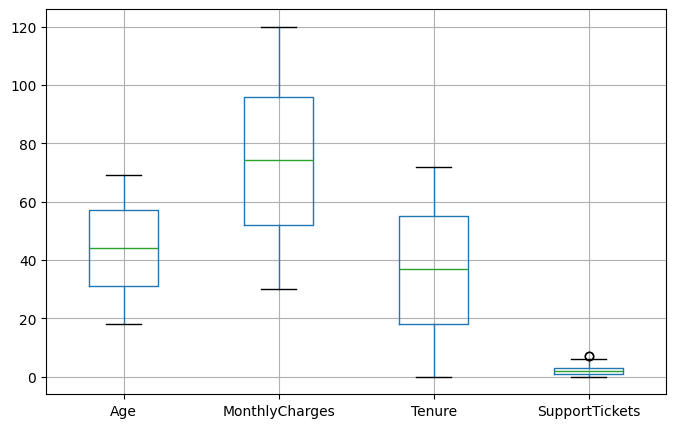

In [100]:
import matplotlib.pyplot as plt

numeric_cols = ['Age', 'MonthlyCharges', 'Tenure', 'SupportTickets']

df[numeric_cols].boxplot(figsize=(8,5))
plt.show()


In [101]:
df['Churn'].value_counts(normalize=True)


,proportion
Churn,
No,0.565
Yes,0.435


In [102]:
df['Tenure_Bucket'] = pd.cut(
    df['Tenure'],
    bins=[0,3,6,12,24,60],
    labels=['0-3','4-6','7-12','13-24','25-60']
)

df.groupby('Tenure_Bucket')['Churn'].value_counts(normalize=True).unstack()


/tmp/ipython-input-1438300117.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Tenure_Bucket')['Churn'].value_counts(normalize=True).unstack()


Churn,No,Yes
Tenure_Bucket,,
0-3,0.346939,0.653061
4-6,0.444444,0.555556
7-12,0.621622,0.378378
13-24,0.552941,0.447059
25-60,0.583851,0.416149


In [103]:
high_charge = df['MonthlyCharges'].quantile(0.75)
df['HighCharges'] = df['MonthlyCharges'] >= high_charge

df.groupby('HighCharges')['Churn'].value_counts(normalize=True).unstack()


Churn,No,Yes
HighCharges,,
False,0.593709,0.406291
True,0.472574,0.527426


In [104]:
df['Tickets_Bucket'] = pd.cut(
    df['SupportTickets'],
    bins=[-1,1,3,6,20],
    labels=['0-1','2-3','4-6','7+']
)

df.groupby('Tickets_Bucket')['Churn'].value_counts(normalize=True).unstack()


/tmp/ipython-input-1799234814.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Tickets_Bucket')['Churn'].value_counts(normalize=True).unstack()


Churn,No,Yes
Tickets_Bucket,,
0-1,0.590206,0.409794
2-3,0.595745,0.404255
4-6,0.392857,0.607143
7+,0.500000,0.500000


In [105]:
df.groupby('ContractType')['Churn'].value_counts(normalize=True).unstack()


Churn,No,Yes
ContractType,,
2-Year,0.689474,0.310526
Annual,0.705085,0.294915
Monthly,0.438835,0.561165


In [106]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})
df.drop(columns=['CustomerID'], inplace=True)



In [107]:
df = pd.get_dummies(
    df,
    columns=['Gender','ContractType','InternetService','PaymentMethod'],
    drop_first=True
)


In [108]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])


In [109]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

df = pd.read_csv("/content/drive/MyDrive/telecom_customer_churn_1000.csv")

df.drop(columns=['CustomerID'], inplace=True)

# Create engineered features (Tenure_Bucket, HighCharges, Tickets_Bucket)
df['Tenure_Bucket'] = pd.cut(
    df['Tenure'],
    bins=[0,3,6,12,24,60],
    labels=['0-3','4-6','7-12','13-24','25-60']
)
high_charge = df['MonthlyCharges'].quantile(0.75)
df['HighCharges'] = df['MonthlyCharges'] >= high_charge
df['Tickets_Bucket'] = pd.cut(
    df['SupportTickets'],
    bins=[-1,1,3,6,20],
    labels=['0-1','2-3','4-6','7+']
)

df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
if 'HighCharges' in categorical_cols:
    categorical_cols.remove('HighCharges')
if 'Churn' in categorical_cols:
    categorical_cols.remove('Churn')

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)
imputer = SimpleImputer(strategy='mean')
cols_to_impute = ['Age', 'MonthlyCharges']
for col in cols_to_impute:
    if col in df.columns and df[col].isnull().any():
        df[col] = imputer.fit_transform(df[[col]])

numeric_cols = ['Age', 'MonthlyCharges', 'Tenure', 'SupportTickets']
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.15,
    stratify=y,
    random_state=42
)

print("Data preprocessing complete and data split into X_train, X_test, y_train, y_test.")

Data preprocessing complete and data split into X_train, X_test, y_train, y_test.


In [110]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=600,
    max_depth=18,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))


Random Forest Accuracy: 0.6666666666666666


In [111]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=2000, class_weight='balanced')
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.6466666666666666


In [112]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("Classification Report:\n", classification_report(y_test, rf_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))


Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.73      0.71        85
           1       0.62      0.58      0.60        65

    accuracy                           0.67       150
   macro avg       0.66      0.66      0.66       150
weighted avg       0.66      0.67      0.67       150

Confusion Matrix:
 [[62 23]
 [27 38]]
ROC-AUC Score: 0.6646153846153847


In [113]:
final_predictions = rf.predict(X)

df_results = pd.DataFrame({
    "Customer_Number": range(1, len(final_predictions)+1),
    "Predicted_Churn": ["Yes" if x==1 else "No" for x in final_predictions]
})

print("\nCHURN PREDICTIONS FOR ALL CUSTOMERS:")
print(df_results.head(20))



CHURN PREDICTIONS FOR ALL CUSTOMERS:
    Customer_Number Predicted_Churn
0                 1             Yes
1                 2             Yes
2                 3             Yes
3                 4             Yes
4                 5             Yes
5                 6             Yes
6                 7              No
7                 8             Yes
8                 9             Yes
9                10              No
10               11              No
11               12              No
12               13              No
13               14              No
14               15              No
15               16             Yes
16               17              No
17               18              No
18               19             Yes
19               20             Yes


In [114]:
print("\nCHURN SUMMARY:")
print(df_results['Predicted_Churn'].value_counts())

print("\nCHURN PERCENTAGE:")
print(df_results['Predicted_Churn'].value_counts(normalize=True) * 100)



CHURN SUMMARY:
Predicted_Churn
No     561
Yes    439
Name: count, dtype: int64

CHURN PERCENTAGE:
Predicted_Churn
No     56.1
Yes    43.9
Name: proportion, dtype: float64


In [115]:
high_risk = (
    (df['Tenure'] < df['Tenure'].quantile(0.25)) &
    (df['MonthlyCharges'] > df['MonthlyCharges'].quantile(0.75)) &
    (df['SupportTickets'] >= 3)
)

print("\nHigh-Risk Customers (Rule-Based):")
print(high_risk.value_counts())



High-Risk Customers (Rule-Based):
False    1000
Name: count, dtype: int64


In [116]:
df['Predicted_Churn'] = [
    "Yes" if x == 1 else "No" for x in final_predictions
]


In [118]:
short_tenure_threshold = df['Tenure'].quantile(0.25)
high_monthly_threshold = df['MonthlyCharges'].quantile(0.75)
high_ticket_threshold = 3

df['Short_Tenure'] = df['Tenure'] <= short_tenure_threshold
df['High_Monthly_Charges'] = df['MonthlyCharges'] >= high_monthly_threshold
df['Many_Support_Tickets'] = df['SupportTickets'] >= high_ticket_threshold
df['Long_Term_Contract'] = (df['ContractType_Monthly'] == 0)

In [119]:
df['High_Churn_Risk'] = (
    (df['Predicted_Churn'] == 'Yes') &
    (
        df['Short_Tenure'] |
        df['High_Monthly_Charges'] |
        df['Many_Support_Tickets']
    )
)


In [120]:
df['High_Churn_Risk'] = (
    (df['Predicted_Churn'] == 'Yes') &
    (
        df['Short_Tenure'] |
        df['High_Monthly_Charges'] |
        df['Many_Support_Tickets']
    )
)


In [121]:
print("\nHIGH-RISK CHURN CUSTOMERS:")
df[df['High_Churn_Risk']].head(20)



HIGH-RISK CHURN CUSTOMERS:


,Age,MonthlyCharges,Tenure,SupportTickets,Churn,HighCharges,Gender_Male,ContractType_Annual,ContractType_Monthly,InternetService_Fiber,...,Tenure_Bucket_25-60,Tickets_Bucket_2-3,Tickets_Bucket_4-6,Tickets_Bucket_7+,Predicted_Churn,Short_Tenure,High_Monthly_Charges,Many_Support_Tickets,Long_Term_Contract,High_Churn_Risk
3,-0.809257,1.707177,1.001331,-1.418675,0,True,False,False,True,True,...,True,False,False,False,Yes,False,True,False,False,True
4,-1.348146,1.304759,1.139981,0.684104,1,True,False,False,True,True,...,False,True,False,False,Yes,False,True,False,False,True
5,-0.876618,1.595678,-0.754904,-1.418675,0,True,True,False,True,True,...,False,False,False,False,Yes,False,True,False,False,True
7,1.009493,0.104179,-1.355721,0.684104,1,False,False,False,True,False,...,False,True,False,False,Yes,True,False,False,False,True
8,0.874771,-1.041043,-1.540587,2.786884,1,False,True,False,True,True,...,False,False,True,False,Yes,True,False,False,False,True
15,-0.270368,1.473186,0.631597,-0.016822,1,True,False,False,True,True,...,True,True,False,False,Yes,False,True,False,False,True
18,0.942132,1.156748,1.139981,-0.717749,1,True,True,False,True,False,...,False,False,False,False,Yes,False,True,False,False,True
19,1.144215,-1.309976,-1.586804,-0.016822,1,False,True,False,True,False,...,False,True,False,False,Yes,True,False,False,False,True
23,0.335882,1.749185,-1.679238,-0.717749,1,True,False,False,True,False,...,False,False,False,False,Yes,True,True,False,False,True
26,-0.539813,0.075912,-1.586804,-0.717749,1,False,True,True,False,False,...,False,False,False,False,Yes,True,False,False,True,True


In [122]:
print("\nLOW CHURN RISK (LONG-TERM CONTRACTS):")
df[
    (df['Long_Term_Contract']) &
    (df['Predicted_Churn'] == 'No')
].head(20)



LOW CHURN RISK (LONG-TERM CONTRACTS):


,Age,MonthlyCharges,Tenure,SupportTickets,Churn,HighCharges,Gender_Male,ContractType_Annual,ContractType_Monthly,InternetService_Fiber,...,Tenure_Bucket_25-60,Tickets_Bucket_2-3,Tickets_Bucket_4-6,Tickets_Bucket_7+,Predicted_Churn,Short_Tenure,High_Monthly_Charges,Many_Support_Tickets,Long_Term_Contract,High_Churn_Risk
9,-1.356459e-01,-1.149794e+00,0.724031,0.684104,0,False,False,True,False,False,...,True,True,False,False,No,False,False,False,True,False
11,9.421316e-01,-4.670580e-01,-1.355721,-0.717749,0,False,True,True,False,False,...,False,False,False,False,No,True,False,False,True,False
12,-2.030070e-01,-6.346995e-01,-0.431387,-0.016822,0,False,False,False,False,True,...,True,True,False,False,No,False,False,False,True,False
13,-1.752312e+00,7.865231e-01,-0.015436,0.684104,0,False,True,True,False,False,...,True,True,False,False,No,False,False,False,True,False
14,-9.439791e-01,-1.643689e+00,-1.494371,0.684104,0,False,False,True,False,False,...,False,True,False,False,No,True,False,False,True,False
16,-3.377292e-01,-7.096866e-01,-1.032204,-0.717749,1,False,True,True,False,True,...,False,False,False,False,No,True,False,False,True,False
17,-1.078701e+00,1.420184e+00,-0.431387,1.385031,0,True,True,False,False,False,...,True,False,True,False,No,False,True,False,True,False
20,1.481020e+00,-4.486057e-01,-0.616253,-0.016822,0,False,True,False,False,False,...,False,True,False,False,No,False,False,False,True,False
27,-6.071736e-01,-3.669443e-01,-0.801120,-0.717749,0,False,False,True,False,True,...,False,False,False,False,No,False,False,False,True,False
29,-1.011340e+00,-1.404594e+00,-0.985987,-0.016822,0,False,True,False,False,False,...,False,True,False,False,No,True,False,False,True,False


In [123]:
sample_customers = pd.DataFrame([
    {
        "CustomerID": "TEST_1",
        "Gender": "Male",
        "Age": 25,
        "MonthlyCharges": 1600,
        "Tenure": 2,
        "ContractType": "Monthly",
        "InternetService": "Fiber",
        "SupportTickets": 4,
        "PaymentMethod": "UPI"
    },
    {
        "CustomerID": "TEST_2",
        "Gender": "Female",
        "Age": 32,
        "MonthlyCharges": 1400,
        "Tenure": 5,
        "ContractType": "Monthly",
        "InternetService": "DSL",
        "SupportTickets": 3,
        "PaymentMethod": "Debit"
    },
    {
        "CustomerID": "TEST_3",
        "Gender": "Male",
        "Age": 45,
        "MonthlyCharges": 600,
        "Tenure": 36,
        "ContractType": "2-Year",
        "InternetService": "Fiber",
        "SupportTickets": 0,
        "PaymentMethod": "Credit Card"
    },
    {
        "CustomerID": "TEST_4",
        "Gender": "Female",
        "Age": 29,
        "MonthlyCharges": 1800,
        "Tenure": 1,
        "ContractType": "Monthly",
        "InternetService": "Fiber",
        "SupportTickets": 5,
        "PaymentMethod": "UPI"
    },
    {
        "CustomerID": "TEST_5",
        "Gender": "Male",
        "Age": 52,
        "MonthlyCharges": 500,
        "Tenure": 48,
        "ContractType": "Annual",
        "InternetService": "DSL",
        "SupportTickets": 1,
        "PaymentMethod": "Cash"
    },
    {
        "CustomerID": "TEST_6",
        "Gender": "Female",
        "Age": 38,
        "MonthlyCharges": 1200,
        "Tenure": 10,
        "ContractType": "Monthly",
        "InternetService": "Fiber",
        "SupportTickets": 2,
        "PaymentMethod": "Debit"
    }
])


In [124]:
sample_ids = sample_customers['CustomerID']
sample_processed = sample_customers.drop(columns=['CustomerID'])
sample_processed = pd.get_dummies(
    sample_processed,
    columns=['Gender','ContractType','InternetService','PaymentMethod'],
    drop_first=True
)
sample_processed = sample_processed.reindex(columns=X.columns, fill_value=0)
sample_processed[numeric_cols] = scaler.transform(sample_processed[numeric_cols])


In [126]:
sample_predictions = rf.predict(sample_processed)
sample_output = sample_customers.copy()

sample_output['Predicted_Churn'] = [
    "Yes" if x == 1 else "No" for x in sample_predictions
]

sample_output


,CustomerID,Gender,Age,MonthlyCharges,Tenure,ContractType,InternetService,SupportTickets,PaymentMethod,Predicted_Churn
0,TEST_1,Male,25,1600,2,Monthly,Fiber,4,UPI,Yes
1,TEST_2,Female,32,1400,5,Monthly,DSL,3,Debit,Yes
2,TEST_3,Male,45,600,36,2-Year,Fiber,0,Credit Card,No
3,TEST_4,Female,29,1800,1,Monthly,Fiber,5,UPI,Yes
4,TEST_5,Male,52,500,48,Annual,DSL,1,Cash,No
5,TEST_6,Female,38,1200,10,Monthly,Fiber,2,Debit,Yes
